# Real-Time Face Mask Compliance Detection

To use the CDS6334 environment, run below conda command:

In [1]:
# conda env export -n CDS6334 > CDS6334.yml

In [2]:
# import libraries
!pip install tensorflow opencv-python matplotlib seaborn scikit-learn
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

print("Libraries installed and imported successfully.")

Libraries installed and imported successfully.


## 1.0 Data Loading

### 1.1 Define Paths

In [3]:
from glob import glob

DATASET_PATH = r"C:\Users\venic\Documents\CDS6334\Real-Time-Face-Mask-Detection-main\Dataset"
class_dirs = ["with_mask", "without_mask", "mask_weared_incorrect"]
print("DATASET_PATH exists:", os.path.exists(DATASET_PATH))
for d in class_dirs:
    p = os.path.join(DATASET_PATH, d)
    print(d, "exists:", os.path.exists(p), "num_images:", len(glob(os.path.join(p, "*.*"))))

DATASET_PATH exists: True
with_mask exists: True num_images: 2994
without_mask exists: True num_images: 2994
mask_weared_incorrect exists: True num_images: 2994


## 2.0 Data Preprocessing

### 2.1 Visual Sanity Check

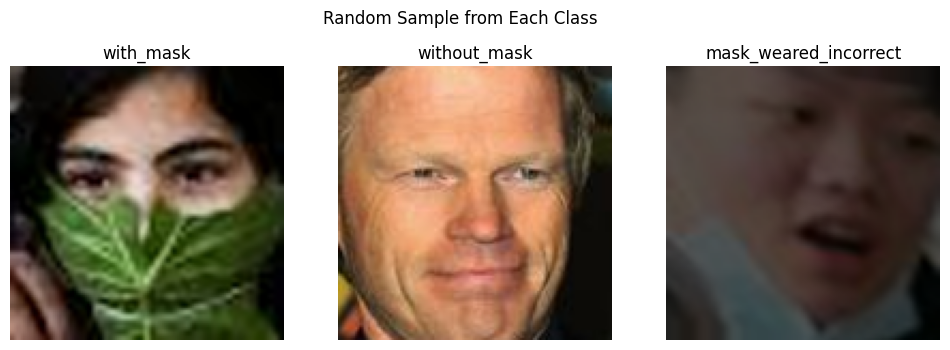

In [4]:
import random

# picks one random image from each of the three folders and displays it 
# on the screen. 
# to ensure the data isn't corrupted and to visually confirm what 
# "Incorrect Mask" looks like. It helps you verify that the dataset is 
# actually cropped faces, not full-body images.

plt.figure(figsize=(12, 4))
for idx, class_name in enumerate(class_dirs):
    img_dir = os.path.join(DATASET_PATH, class_name)
    img_files = glob(os.path.join(img_dir, "*.*"))
    if not img_files:
        print(f"No images found in {class_name}")
        continue
    img_path = random.choice(img_files)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, 3, idx + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')
plt.suptitle("Random Sample from Each Class")
plt.show()

### 2.2 Configuration and Data Augmentation

In [5]:
# This sets up the ImageDataGenerator. This is a tool that:
# 1. Rescales: Converts pixel colors from 0-255 to 0-1 (Neural networks like small numbers).
# 2. Splits: Automatically reserves 20% of the data for testing (Validation).
# 3. Augments: Defines rules to randomly rotate, zoom, or shift images during training. Why it is needed: Augmentation is critical for your project because "Incorrect Mask" detection is subtle. By randomly tilting images, we teach the model to recognize a nose slipping out even if the person's head isn't perfectly straight.
# Set up ImageDataGenerator for training and validation
train_datagen = ImageDataGenerator(
    rotation_range=15,             # 3. Randomly rotate images by up to 15 degrees
    width_shift_range=0.1,         # 3. Randomly shift images horizontally
    height_shift_range=0.1,        # 3. Randomly shift images vertically
    zoom_range=0.1,                # 3. Randomly zoom images
    horizontal_flip=True,          # 3. Randomly flip images horizontally
    validation_split=0.2           # 2. Reserve 20% of data for validation
)
print("ImageDataGenerator configured for augmentation and validation split.")

ImageDataGenerator configured for augmentation and validation split.


### 2.3 Create Train and Validation Generators

In [6]:
# This actually connects the datagen (the rules) to your DATASET_PATH 
# (the files). It creates two "streams" of data: train_gen and val_gen. 
# These two variables (train_gen and val_gen) are what you will feed 
# directly into the model training command (model.fit) in Section 3.0.
# Create training and validation data generators
train_gen = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)
print(f"[INFO] Training generator: Found {train_gen.samples} images belonging to {train_gen.num_classes} classes. These will be used for training.")

val_gen = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)
print(f"[INFO] Validation generator: Found {val_gen.samples} images belonging to {val_gen.num_classes} classes. These will be used for validation.")

Found 7188 images belonging to 3 classes.
[INFO] Training generator: Found 7188 images belonging to 3 classes. These will be used for training.
Found 1794 images belonging to 3 classes.
[INFO] Validation generator: Found 1794 images belonging to 3 classes. These will be used for validation.


## 3.0 Model A: EfficientNet-B0

### 3.1 Build Architecture

In [7]:
# Load the EfficientNetB0 model pre-trained on ImageNet.
# include_top=False removes the final classification layer (which was made for 1000 objects like cats/dogs).
# Then add our own "Custom Head" to classify your 3 specific mask categories.

# 1. Load the base model with pre-trained ImageNet weights
base_model_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze the base model
# This ensures we don't destroy the pre-learned features (like edges and shapes) during the initial training.
base_model_eff.trainable = False 

# 3. Add Custom Head
x = base_model_eff.output
x = GlobalAveragePooling2D()(x)                # Summarize the features
x = Dense(256, activation='relu')(x)           # specific layer to learn mask patterns
x = Dropout(0.5)(x)                            # Dropout prevents overfitting
predictions = Dense(3, activation='softmax')(x) # Final layer: 3 Neurons for 3 Classes (Softmax for probability)

# 4. Construct the final model
model_eff = Model(inputs=base_model_eff.input, outputs=predictions)

# 5. Compile the model
# use Adam optimizer and Categorical Crossentropy as we have more than 2 classes.
model_eff.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

print("EfficientNet-B0 model built and compiled successfully.")
model_eff.summary()

EfficientNet-B0 model built and compiled successfully.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,378,278 (16.70 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

### 3.2 Train Model

In [ ]:
# This fits the model to your training data. 
# We use 15 epochs as planned. The 'val_gen' is used to check performance after every epoch.

print("Starting training for EfficientNet-B0...")

history_eff = model_eff.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    steps_per_epoch=len(train_gen),
    validation_steps=len(val_gen)
)

print("Training completed.")

# Save the trained model for later use in the Application Simulation (Section 6.0)
model_eff.save('mask_detector_efficientnet.h5')
print("Model saved as 'mask_detector_efficientnet.h5'")

Starting training for EfficientNet-B0...


e:\Program Files\Anaconda\envs\CDS6334\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 118s 495ms/step - accuracy: 0.8959 - loss: 0.2535 - val_accuracy: 0.9732 - val_loss: 0.0721
Epoch 2/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 109s 483ms/step - accuracy: 0.9747 - loss: 0.0672 - val_accuracy: 0.9732 - val_loss: 0.0770
Epoch 3/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 109s 482ms/step - accuracy: 0.9810 - loss: 0.0624 - val_accuracy: 0.9766 - val_loss: 0.0727
Epoch 4/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 109s 485ms/step - accuracy: 0.9832 - loss: 0.0433 - val_accuracy: 0.9833 - val_loss: 0.0503
Epoch 5/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 109s 482ms/step - accuracy: 0.9879 - loss: 0.0362 - val_accuracy: 0.9833 - val_loss: 0.0558
Epoch 6/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 108s 480ms/step - accuracy: 0.9872 - loss: 0.0384 - val_accuracy: 0.9849 - val_loss: 0.0478
Epoch 7/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 109s 487ms/step - accuracy: 0.9872 - loss: 0.0336 - val_accuracy: 0.9833 - val_loss: 0.0501
Epoch 8/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 109s 486ms/step - accuracy: 0.9911 -

Training completed.
Model saved as 'mask_detector_efficientnet.h5'


## 4.0 Model B: MobileNetV2

### 4.1 Build and Train

In [9]:
# Performs the exact same steps as Section 3.0, but swaps the "Brain" for MobileNetV2.
# To ensure a fair comparison, we use the exact same data, same optimizer, and same output layers. The only variable changing is the architecture.

## 5.0 Comparative Evaluation

### 5.1 Training History Plots

In [10]:
# Draws line graphs comparing how both models learned.
# To check if one model learned faster or if one model "overfit" (memorized the data instead of learning).

### 5.2 Confusion Matrix & Classification Report

In [11]:
# Generates the "Report Card". It tells you exactly which classes were confused.
# Pay attention to the F1-Score for mask_weared_incorrect.
# This proves which model is safer. If EfficientNet has fewer False Negatives on incorrect masks, it wins on "Safety".

### 5.3 Inference Speed Test (FPS)

In [12]:
# Runs 100 dummy images through both models and times them.
# This is the key metric for MobileNet. You expect MobileNet to be faster. This data point goes into your "Results" table.

## 6.0 Application Simulation (Access Control)